# TxCat — Robust Bank Transaction Categorization
## under Merchant, Format, and Data-Distribution Shift

**Dataset:** `DoDataThings/us-bank-transaction-categories-v2` (HuggingFace, MIT)

**Canonical implementation:** `transactions.py` — this notebook executes that
pipeline live. Every number below is produced from actual execution in this
session.

### Central research question
> Can transaction-categorization models learn generalizable transaction
> semantics and banking-language patterns rather than simply memorizing
> merchant identities and formatting artifacts?

### Controlled benchmark
This is a **synthetic** bank-transaction dataset with realistic description
formats (Chase ACH, PayPal, Square/Toast/Clover POS, Capital One, Apple Card
addresses, simple). It is a **controlled synthetic bank-transaction benchmark**;
results here do **not** estimate bank-production performance.

### Method summary
| Layer | Technique |
|---|---|
| Representation | word TF-IDF (1–2 g) · char TF-IDF (3–5 g) · sparse hybrid |
| Structured | debit/credit direction · length/digit/punctuation stats |
| Classifiers | Logistic Regression · Linear SVM · XGBoost |
| Robustness | merchant-disjoint split · format-disjoint split · merchant masking |
| Reliability | calibration · confidence-aware selective prediction |
| Data-centric | learning curve · feature ablation · error analysis |

**Reproducibility:** `RANDOM_STATE = 42` everywhere; TF-IDF fit on train only;
no test-set calibration; fixed test set for learning curves.

## 1. Problem Definition

**Objective** — predict one of 17 transaction categories from a short,
noisy bank-statement description.

**Experimental approach** — this is a single-dataset, data-centric study. We
isolate the effect of (a) text representation, (b) structured direction,
(c) merchant identity, and (d) transaction-format artifacts on generalization.

**Design principle** — no algorithm zoo. Every experiment answers one
question tied to the central research question: does the model learn
transaction *semantics* or memorize merchant/format *surface* cues?

In [1]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sys.path.insert(0, ".")

import transactions as tx

print("module ok")

module ok


## 2. Dataset & Data Quality

**Objective** — load the canonical dataset, validate the schema, and quantify
missingness, duplicates, class balance, direction, formats and merchants.

**Method** — `transactions.load_raw_dataframe` + `inspect_schema` +
field extraction (direction, merchant, format, city).

**Result** — counts below are computed from the loaded data (not assumed).

In [2]:
df = tx.load_raw_dataframe(tx.DATASET_ID)
print("rows:", len(df))
print("columns:", list(df.columns))
df.head()

2026-08-18 01:07:15 | INFO     | Loading DoDataThings/us-bank-transaction-categories-v2 …


2026-08-18 01:07:15 | INFO     | HTTP Request: HEAD https://huggingface.co/datasets/DoDataThings/us-bank-transaction-categories-v2/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"


2026-08-18 01:07:16 | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/DoDataThings/us-bank-transaction-categories-v2/3e8d052cb7b362fb1a04b6064d2331982553ea56/README.md "HTTP/1.1 200 OK"


2026-08-18 01:07:16 | INFO     | HTTP Request: HEAD https://huggingface.co/datasets/DoDataThings/us-bank-transaction-categories-v2/resolve/3e8d052cb7b362fb1a04b6064d2331982553ea56/us-bank-transaction-categories-v2.py "HTTP/1.1 404 Not Found"


2026-08-18 01:07:17 | INFO     | HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/DoDataThings/us-bank-transaction-categories-v2/DoDataThings/us-bank-transaction-categories-v2.py "HTTP/1.1 404 Not Found"


...

2026-08-18 01:07:19 | INFO     | HTTP Request: GET https://huggingface.co/api/datasets/DoDataThings/us-bank-transaction-categories-v2/tree/3e8d052cb7b362fb1a04b6064d2331982553ea56?recursive=false&expand=false "HTTP/1.1 200 OK"


2026-08-18 01:07:19 | INFO     | HTTP Request: HEAD https://huggingface.co/datasets/DoDataThings/us-bank-transaction-categories-v2/resolve/3e8d052cb7b362fb1a04b6064d2331982553ea56/dataset_infos.json "HTTP/1.1 404 Not Found"


2026-08-18 01:07:19 | INFO     | Loaded 68000 rows, columns=['description', 'category']


rows: 68000
columns: ['description', 'category']


,description,category
0,[debit] NORTHWESTERN MUTUALEFT PYMT PPD ID: 99...,Insurance
1,[debit] MTG PMT PENFED CU,Mortgage
2,[debit] BETMGM 147 PARK BLVD UNION CITY 94587 ...,Entertainment
3,[debit] REPUBLIC SERVICES 222 MISSION CT CHICA...,Utilities
4,[debit] PYPL*365 MARKET,Groceries


In [3]:
schema = tx.inspect_schema(df)
pd.DataFrame(schema["columns"]).assign(n_rows=schema["n_rows"])

,column,dtype,missing,missing_pct,unique,role,n_rows
0,description,object,0,0.0,45697,transaction text,68000
1,category,object,0,0.0,17,target category,68000


In [4]:
df["direction"] = df["description"].apply(tx.extract_direction)
df["merchant"] = df["description"].apply(tx.extract_merchant)
df["format"] = df["description"].apply(tx.detect_format)
df["city"] = df["description"].apply(tx.extract_city)
df["text_basic"] = df["description"].apply(tx.normalize_basic)
df["text_structured"] = df["description"].apply(tx.normalize_structured)

summary = {
    "rows": int(len(df)),
    "categories": int(df["category"].nunique()),
    "merchants": int(df["merchant"].nunique()),
    "cities": int(df["city"].nunique()),
    "formats": {k: int(v) for k, v in df["format"].value_counts().items()},
    "direction": {k: int(v) for k, v in df["direction"].value_counts().items()},
    "duplicate_descriptions": int(df["description"].duplicated().sum()),
    "duplicate_full_rows": int(df.duplicated().sum()),
    "class_distribution": {k: int(v) for k, v in df["category"].value_counts().items()},
}
Path("out").mkdir(exist_ok=True)
tx.write_json(summary, Path("out") / "dataset_summary.json")
print(json.dumps(summary, indent=2))

{
  "rows": 68000,
  "categories": 17,
  "merchants": 12918,
  "cities": 35,
  "formats": {
    "simple": 45386,
    "ach": 8272,
    "paypal": 5732,
    "address": 4670,
    "capital_one": 2791,
    "pos": 1149
  },
  "direction": {
    "debit": 60007,
    "credit": 7993
  },
  "duplicate_descriptions": 22303,
  "duplicate_full_rows": 22298,
  "class_distribution": {
    "Insurance": 4000,
    "Mortgage": 4000,
    "Entertainment": 4000,
    "Utilities": 4000,
    "Groceries": 4000,
    "Personal Care": 4000,
    "Shopping": 4000,
    "Subscription": 4000,
    "Healthcare": 4000,
    "Rent": 4000,
    "Fees": 4000,
    "Income": 4000,
    "Transportation": 4000,
    "Education": 4000,
    "Restaurants": 4000,
    "Transfer": 4000,
    "Travel": 4000
  }
}


In [5]:
print("Class distribution (count | %):")
dist = df["category"].value_counts()
tab = pd.DataFrame({"count": dist, "percent": (dist / len(df) * 100).round(2)})
tab

Class distribution (count | %):


,count,percent
category,,
Insurance,4000,5.88
Mortgage,4000,5.88
Entertainment,4000,5.88
Utilities,4000,5.88
Groceries,4000,5.88
Personal Care,4000,5.88
Shopping,4000,5.88
Subscription,4000,5.88
Healthcare,4000,5.88


In [6]:
print("Direction distribution:")
print(df["direction"].value_counts())
print()
print("Transaction-format families detected:")
print(df["format"].value_counts().to_string())
print()
print(f"Duplicate descriptions: {summary['duplicate_descriptions']:,} "
      f"({summary['duplicate_descriptions'] / len(df):.1%})")
print(f"Duplicate full rows:    {summary['duplicate_full_rows']:,}")

Direction distribution:
direction
debit     60007
credit     7993
Name: count, dtype: int64

Transaction-format families detected:
format
simple         45386
ach             8272
paypal          5732
address         4670
capital_one     2791
pos             1149

Duplicate descriptions: 22,303 (32.8%)
Duplicate full rows:    22,298


## 3. Exploratory Data Analysis

**Objective** — understand what the descriptions look like and which surface
cues correlate with categories. Every plot below motivates a later experiment.

**Method** — description length/digit/punct profiles, category × direction,
merchant long tail, and format × category overlap.

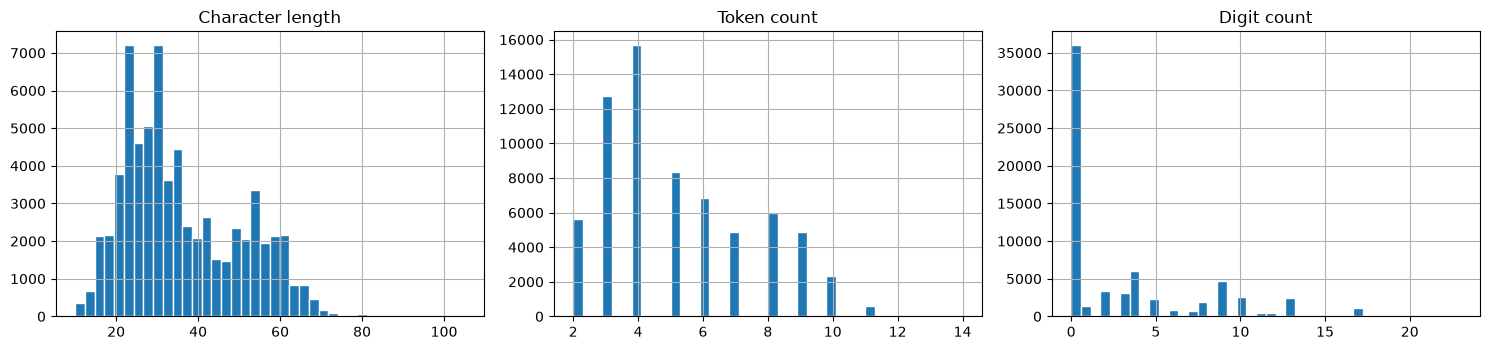

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
feats = tx.structural_features(df)
feats[["char_count", "token_count", "digit_count"]].hist(
    bins=40, ax=axes, edgecolor="white"
)
axes[0].set_title("Character length"); axes[1].set_title("Token count"); axes[2].set_title("Digit count")
plt.tight_layout(); plt.show()

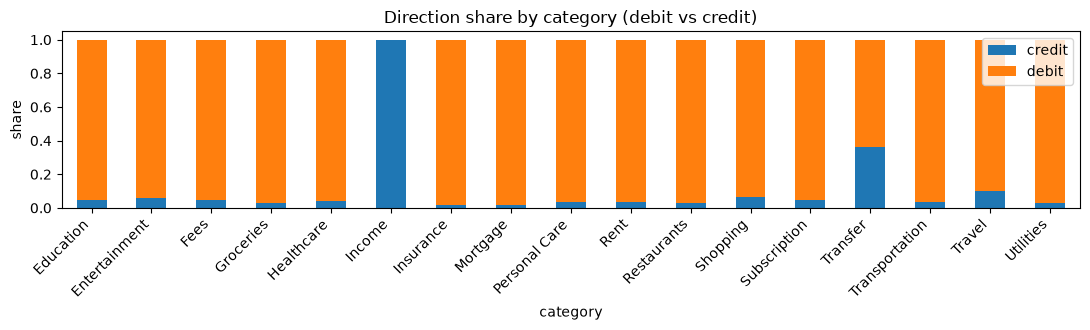

In [8]:
# category × direction heatmap
ct = pd.crosstab(df["category"], df["direction"], normalize="index")
ct.plot(kind="bar", figsize=(11, 3.4), stacked=True)
plt.title("Direction share by category (debit vs credit)")
plt.ylabel("share"); plt.xticks(rotation=45, ha="right"); plt.legend(loc="upper right")
plt.tight_layout(); plt.show()

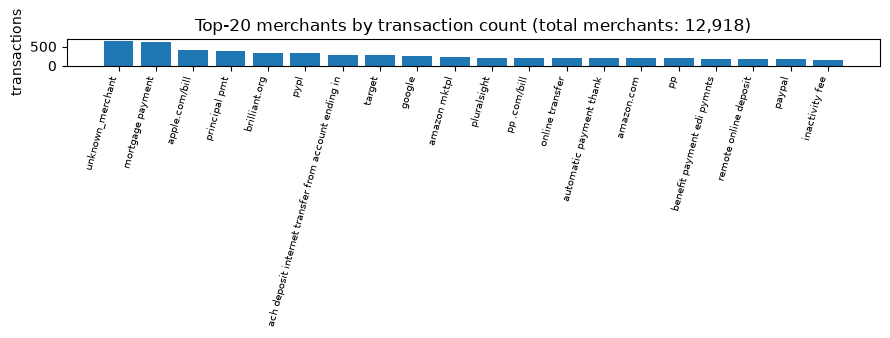

Merchant long tail: share of merchants with a single transaction = 61.1%


In [9]:
# merchant long tail
mc = df["merchant"].value_counts()
top = mc.head(20)
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(range(len(top)), top.values)
ax.set_xticks(range(len(top)))
ax.set_xticklabels(top.index, rotation=75, ha="right", fontsize=7)
ax.set_ylabel("transactions")
ax.set_title(f"Top-20 merchants by transaction count (total merchants: {df['merchant'].nunique():,})")
plt.tight_layout(); plt.show()

print("Merchant long tail: share of merchants with a single transaction =",
      f"{(mc == 1).mean():.1%}")

In [10]:
# format × category concentration (which categories rely on which formats)
fmt_cat = pd.crosstab(df["format"], df["category"], normalize="index")
print(fmt_cat.round(3).head(10).to_string())

category     Education  Entertainment   Fees  Groceries  Healthcare  Income  Insurance  Mortgage  Personal Care   Rent  Restaurants  Shopping  Subscription  Transfer  Transportation  Travel  Utilities
format                                                                                                                                                                                                  
ach              0.000          0.000  0.000      0.000       0.013   0.168      0.199     0.148          0.000  0.189        0.000     0.000         0.000     0.089           0.008   0.000      0.186
address          0.061          0.090  0.000      0.097       0.057   0.000      0.149     0.000          0.097  0.000        0.100     0.055         0.085     0.000           0.052   0.074      0.083
capital_one      0.072          0.088  0.000      0.000       0.038   0.000      0.000     0.063          0.118  0.191        0.000     0.000         0.000     0.050           0.038   0.101      0

In [11]:
# sample descriptions per category
for c in ["Groceries", "Income", "Transfer", "Utilities"]:
    print(f"== {c} ==")
    for d in df[df.category == c].description.head(3):
        print("   ", d)
    print()

== Groceries ==
    [debit] PYPL*365 MARKET
    [debit] PUBLIX 7860 UNIVERSITY LN OAKLAND 94601-4574CA USA
    [debit] GROCOUTLT #47001 HOUSTON

== Income ==
    [credit] US GOVERNMENT DIR DEP PPD ID: 547185326
    [credit] Payment Refund: ASOS
    [credit] SALESFORCE PAYROLL

== Transfer ==
    [debit] MERRILL LYNCH INVESTMENTS MONEYLINE
    [debit] MONTHLY INSTALLMENTS (11 OF 12)
    [debit] MONTHLY INSTALLMENTS (10 OF 24)

== Utilities ==
    [debit] REPUBLIC SERVICES 222 MISSION CT CHICAGO60601 IL USA
    [debit] MUNICIPAL WATER UTIL PMT WEB ID: 1P3K5KBY
    [debit] republic services 1128 main st raleigh 27601-7390nc usa



## 4. Transaction Text Normalization

**Objective** — determine whether arbitrary instance identifiers (order IDs,
reference codes, store numbers) hurt generalization by letting the model
memorize instance-level noise.

**Method** — three controlled representations:

- **A. Raw / minimal** — direction tag stripped, whitespace collapsed.
- **B. Normalized** — lowercase, collapsed whitespace (structure preserved).
- **C. Structure-aware** — numeric order/ref/store tokens replaced with
  `<REF>` / `<STORE>` / `<NUM>` placeholders.

**Result** — examples of each representation.

In [12]:
samples = df["description"].head(6).tolist()
for s in samples:
    print("RAW :", s)
    print("BAS :", tx.normalize_basic(s))
    print("STR :", tx.normalize_structured(s))
    print()

RAW : [debit] NORTHWESTERN MUTUALEFT PYMT PPD ID: 9901629141
BAS : northwestern mutualeft pymt ppd id: 9901629141
STR : northwestern mutualeft pymt <ref>

RAW : [debit] MTG PMT PENFED CU
BAS : mtg pmt penfed cu
STR : mtg pmt penfed cu

RAW : [debit] BETMGM 147 PARK BLVD UNION CITY 94587 CA USA
BAS : betmgm 147 park blvd union city 94587 ca usa
STR : betmgm 147 park blvd union city <num> ca usa

RAW : [debit] REPUBLIC SERVICES 222 MISSION CT CHICAGO60601 IL USA
BAS : republic services 222 mission ct chicago60601 il usa
STR : republic services 222 mission ct chicago60601 il usa

RAW : [debit] PYPL*365 MARKET
BAS : pypl*365 market
STR : pypl <ref> market

RAW : [debit] PUBLIX 7860 UNIVERSITY LN OAKLAND 94601-4574CA USA
BAS : publix 7860 university ln oakland 94601-4574ca usa
STR : publix <num> university ln oakland <num> -4574ca usa



In [13]:
df["text_raw"] = df["description"].apply(tx.normalize_raw)
df["text_basic"] = df["description"].apply(tx.normalize_basic)
df["text_structured"] = df["description"].apply(tx.normalize_structured)

# how much token mass does structure-masking remove?
raw_tokens = df["text_basic"].str.split().str.len()
masked_tokens = df["text_structured"].str.split().str.len()
print(f"Mean tokens  basic: {raw_tokens.mean():.2f}")
print(f"Mean tokens  structured: {masked_tokens.mean():.2f}")
print(f"Mean tokens  removed by masking: {(raw_tokens - masked_tokens).mean():.2f}")

Mean tokens  basic: 4.18
Mean tokens  structured: 3.99
Mean tokens  removed by masking: 0.19


## 5. Evaluation Design

**Objective** — define a fair, leak-free evaluation protocol.

**Method**

1. Stratified **random split** (80/20) for the standard benchmark.
2. **Merchant-disjoint split** (grouped by extracted merchant key, zero
   overlap) for the generalization benchmark.
3. **TF-IDF fit on training split only**; test set untouched.
4. Fixed `RANDOM_STATE = 42`.
5. Metrics: **Accuracy, Macro-F1 (primary), Weighted-F1**, per-class F1.

**Caveat on merchant identity.** `merchant` is a heuristic key extracted
from the description by `transactions.extract_merchant` (regex-based
wrapper stripping + head-of-string truncation).  Two surface variants of
the same brand (e.g. `CHASE MOBILE` and `CHASE ACH`) can map to
different keys, so the merchant-disjoint split is disjoint *by extracted
key*, not by ground-truth brand.  Numbers should be read as an
*upper bound* on the memorization gap.

**Result** — split sizes and merchant-overlap statistics.

In [14]:
from sklearn.model_selection import train_test_split

train_df, test_df = tx.make_splits(df, test_size=0.2, seed=42)
print(f"Random split: train {len(train_df):,} / test {len(test_df):,}")

g_train, g_test, split_info = tx.merchant_disjoint_split(df, test_size=0.2, seed=42)
print(f"Merchant-disjoint: train {len(g_train):,} / test {len(g_test):,}")
print("Merchant overlap (must be 0):", split_info["merchant_overlap"])

overlap = tx.merchant_overlap_fraction(train_df, test_df)
print(f"Random split merchant overlap (test rows sharing a merchant with train): {overlap:.1%}")
print(f"Unique merchants: {df['merchant'].nunique():,}")

Random split: train 54,400 / test 13,600
Merchant-disjoint: train 52,686 / test 15,314
Merchant overlap (must be 0): 0
Random split merchant overlap (test rows sharing a merchant with train): 87.7%
Unique merchants: 12,918


## 6. Baseline Text Classification — Word TF-IDF + Logistic Regression

**Objective** — establish the baseline on the standard random split.

**Method** — `TfidfVectorizer(analyzer="word", ngram_range=(1,2))`,
15,000 features, `sublinear_tf`, fitted on train only; multinomial
Logistic Regression.

**Result** — baseline metrics.

In [15]:
wv = tx.fit_word_tfidf(train_df["description"], max_features=15_000)
Xtr_w, Xte_w = tx.vectorize_pair(wv, train_df["description"], test_df["description"])
print("Train:", Xtr_w.shape, " Test:", Xte_w.shape)

Train: (54400, 13042)  Test: (13600, 13042)


In [16]:
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression(max_iter=8000, solver="lbfgs", random_state=42).fit(
    Xtr_w, train_df["category"].values
)
base_metrics = tx.evaluate_model(
    baseline, Xte_w, test_df["category"].values,
    sorted(train_df["category"].unique()), "baseline word-LR",
)
print("Accuracy:", base_metrics["accuracy"])
print("Macro-F1:", base_metrics["macro_f1"])
print("Weighted-F1:", base_metrics["weighted_f1"])

2026-08-18 01:07:30 | INFO     | baseline word-LR — Acc 0.9946  Macro-F1 0.9946  W-F1 0.9946


Accuracy: 0.9946
Macro-F1: 0.9946
Weighted-F1: 0.9946


## 7. Character-Level NLP

**Objective** — test whether character n-grams add signal beyond words.

**Rationale** — transaction descriptions are full of prefixes, abbreviations,
compressed merchant names (`DAVESHOTCHICKEN`), IDs, and spacing quirks that
word tokenization destroys.

**Method** — `TfidfVectorizer(analyzer="char", ngram_range=(3,5))`, 20,000
features, same split and classifier as Section 6.

In [17]:
cv = tx.fit_char_tfidf(train_df["description"], max_features=20_000)
Xtr_c, Xte_c = tx.vectorize_pair(cv, train_df["description"], test_df["description"])
print("Train:", Xtr_c.shape, " Test:", Xte_c.shape)

Train: (54400, 20000)  Test: (13600, 20000)


In [18]:
char_lr = LogisticRegression(max_iter=8000, solver="lbfgs", random_state=42).fit(
    Xtr_c, train_df["category"].values
)
char_metrics = tx.evaluate_model(
    char_lr, Xte_c, test_df["category"].values,
    sorted(train_df["category"].unique()), "char-LR",
)
print("Accuracy:", char_metrics["accuracy"])
print("Macro-F1:", char_metrics["macro_f1"])

2026-08-18 01:07:48 | INFO     | char-LR — Acc 0.9918  Macro-F1 0.9917  W-F1 0.9917


Accuracy: 0.9918
Macro-F1: 0.9917


## 8. Hybrid Text Representation

**Objective** — combine word + character evidence.

**Method** — `scipy.sparse.hstack` of the word and char TF-IDF matrices (no
densification), same Logistic Regression, same split.

**Result** — hybrid vs word vs char. This isolates the representation effect.

In [19]:
from scipy.sparse import hstack

Xtr_h = hstack([Xtr_w, Xtr_c], format="csr")
Xte_h = hstack([Xte_w, Xte_c], format="csr")
print("Hybrid:", Xtr_h.shape, Xte_h.shape)

Hybrid: (54400, 33042) (13600, 33042)


In [20]:
hybrid_lr = LogisticRegression(max_iter=8000, solver="lbfgs", random_state=42).fit(
    Xtr_h, train_df["category"].values
)
hybrid_metrics = tx.evaluate_model(
    hybrid_lr, Xte_h, test_df["category"].values,
    sorted(train_df["category"].unique()), "hybrid-LR",
)
print("Accuracy:", hybrid_metrics["accuracy"])
print("Macro-F1:", hybrid_metrics["macro_f1"])

2026-08-18 01:08:00 | INFO     | hybrid-LR — Acc 0.9965  Macro-F1 0.9965  W-F1 0.9965


Accuracy: 0.9965
Macro-F1: 0.9965


In [21]:
rep_compare = pd.DataFrame({
    "Representation": ["Word", "Character", "Word + Character"],
    "Accuracy": [base_metrics["accuracy"], char_metrics["accuracy"], hybrid_metrics["accuracy"]],
    "Macro-F1": [base_metrics["macro_f1"], char_metrics["macro_f1"], hybrid_metrics["macro_f1"]],
    "Weighted-F1": [base_metrics["weighted_f1"], char_metrics["weighted_f1"], hybrid_metrics["weighted_f1"]],
})
rep_compare

,Representation,Accuracy,Macro-F1,Weighted-F1
0,Word,0.9946,0.9946,0.9946
1,Character,0.9918,0.9917,0.9917
2,Word + Character,0.9965,0.9965,0.9965


## 9. Structured Feature Ablation

**Objective** — measure the incremental value of (a) debit/credit direction
and (b) structural text statistics beyond raw text.

**Method** — sparse hybrid text features stacked with direction one-hots and
structural features. Four feature sets, same split and classifier.

**Result** — ablation table.

In [22]:
abl = tx.feature_ablation(train_df, test_df, seed=42)
abl_df = pd.DataFrame(abl).T.reset_index().rename(columns={"index": "Feature set"})
abl_df

2026-08-18 01:08:07 | INFO     | logreg · word — Acc 0.9946  Macro-F1 0.9946  W-F1 0.9946


2026-08-18 01:08:25 | INFO     | logreg · char — Acc 0.9918  Macro-F1 0.9917  W-F1 0.9917


2026-08-18 01:08:43 | INFO     | logreg · hybrid — Acc 0.9965  Macro-F1 0.9965  W-F1 0.9965


2026-08-18 01:09:06 | INFO     | logreg · hybrid — Acc 0.9967  Macro-F1 0.9967  W-F1 0.9967


2026-08-18 01:19:46 | INFO     | logreg · hybrid — Acc 0.9960  Macro-F1 0.9959  W-F1 0.9959


,Feature set,accuracy,macro_f1,weighted_f1
0,word,0.9946,0.9946,0.9946
1,char,0.9918,0.9917,0.9917
2,word+char,0.9965,0.9965,0.9965
3,word+char+dir,0.9967,0.9967,0.9967
4,word+char+dir+struct,0.9960,0.9959,0.9959


In [23]:
tx.write_json(abl, Path("out") / "feature_ablation.json")
print("saved out/feature_ablation.json")

saved out/feature_ablation.json


## 10. Model Comparison

**Objective** — compare three classifiers on the *same* representation,
split, and metrics: Logistic Regression, Linear SVM, XGBoost.

**Method** — hybrid text + direction + structural features. Small, sensible
hyperparameters; identical evaluation. The goal is scientific comparison, not
leaderboard optimization. If linear models win, we say so.

In [24]:
labels = sorted(train_df["category"].unique())
Xtr_full = tx.build_feature_matrix(Xtr_h, train_df, use_direction=True, use_structural=True)
Xte_full = tx.build_feature_matrix(Xte_h, test_df, use_direction=True, use_structural=True)
print("Full feature matrix:", Xtr_full.shape)

Full feature matrix: (54400, 33051)


In [25]:
from sklearn.svm import LinearSVC

models = {}
metrics = {}

# Logistic Regression
models["logreg"] = LogisticRegression(max_iter=8000, solver="lbfgs", random_state=42).fit(
    Xtr_full, train_df["category"].values
)
metrics["logreg"] = tx.evaluate_model(
    models["logreg"], Xte_full, test_df["category"].values, labels, "LogReg · full"
)

# Linear SVM
models["linearsvc"] = LinearSVC(max_iter=8000, random_state=42).fit(
    Xtr_full, train_df["category"].values
)
metrics["linearsvc"] = tx.evaluate_model(
    models["linearsvc"], Xte_full, test_df["category"].values, labels, "LinearSVC · full"
)

2026-08-18 01:29:22 | INFO     | LogReg · full — Acc 0.9960  Macro-F1 0.9959  W-F1 0.9959


2026-08-18 01:31:08 | INFO     | LinearSVC · full — Acc 0.9988  Macro-F1 0.9987  W-F1 0.9987


In [26]:
# XGBoost — deliberately bounded capacity
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder().fit(labels)
y_enc = le.transform(train_df["category"].values)

xgb_model = xgb.XGBClassifier(
    objective="multi:softprob", num_class=len(labels), n_estimators=200,
    max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, tree_method="hist", verbosity=0,
).fit(Xtr_full, y_enc)
xgb_wrap = tx.XGBStringWrapper(xgb_model, le)
metrics["xgboost"] = tx.evaluate_model(
    xgb_wrap, Xte_full, test_df["category"].values, labels, "XGBoost · full"
)
models["xgboost"] = xgb_wrap

2026-08-18 01:49:13 | INFO     | XGBoost · full — Acc 0.9903  Macro-F1 0.9902  W-F1 0.9902


In [27]:
model_compare = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM", "XGBoost"],
    "Accuracy": [metrics["logreg"]["accuracy"], metrics["linearsvc"]["accuracy"], metrics["xgboost"]["accuracy"]],
    "Macro-F1": [metrics["logreg"]["macro_f1"], metrics["linearsvc"]["macro_f1"], metrics["xgboost"]["macro_f1"]],
    "Weighted-F1": [metrics["logreg"]["weighted_f1"], metrics["linearsvc"]["weighted_f1"], metrics["xgboost"]["weighted_f1"]],
})
model_compare

,Model,Accuracy,Macro-F1,Weighted-F1
0,Logistic Regression,0.9960,0.9959,0.9959
1,Linear SVM,0.9988,0.9987,0.9987
2,XGBoost,0.9903,0.9902,0.9902


In [28]:
tx.write_json({k: v for k, v in metrics.items()}, Path("out") / "classification_metrics.json")
print("saved out/classification_metrics.json")

saved out/classification_metrics.json


## 11. Merchant-Disjoint Generalization (core experiment)

**Objective** — does the model generalize to merchants it has never seen, or
does it memorize merchant identity?

**Method** — grouped split by extracted merchant key with **zero overlap**
(verified). Same features, same classifiers, same hyperparameters.

**Result** — performance degradation from random → merchant-disjoint split
is the key evidence about memorization vs. learning.

In [29]:
g_train, g_test, split_info = tx.merchant_disjoint_split(df, test_size=0.2, seed=42)
print("Merchant overlap (must be 0):", split_info["merchant_overlap"])
print(f"train {len(g_train):,} / test {len(g_test):,}")

Merchant overlap (must be 0): 0
train 52,686 / test 15,314


In [30]:
g_labels = sorted(g_train["category"].unique())

gwv = tx.fit_word_tfidf(g_train["description"], max_features=15_000)
gcv = tx.fit_char_tfidf(g_train["description"], max_features=20_000)
gXw_tr, gXw_te = tx.vectorize_pair(gwv, g_train["description"], g_test["description"])
gXc_tr, gXc_te = tx.vectorize_pair(gcv, g_train["description"], g_test["description"])
gX_tr = hstack([gXw_tr, gXc_tr], format="csr")
gX_te = hstack([gXw_te, gXc_te], format="csr")
gX_tr = tx.build_feature_matrix(gX_tr, g_train, use_direction=True)
gX_te = tx.build_feature_matrix(gX_te, g_test, use_direction=True)

gen_metrics = {}
for name, mk in [
    ("logreg", lambda: LogisticRegression(max_iter=8000, solver="lbfgs", random_state=42)),
    ("linearsvc", lambda: LinearSVC(max_iter=8000, random_state=42)),
]:
    m = mk().fit(gX_tr, g_train["category"].values)
    gen_metrics[name] = tx.evaluate_model(m, gX_te, g_test["category"].values, g_labels, f"{name} · merchant-disjoint")


2026-08-18 01:49:54 | INFO     | logreg · merchant-disjoint — Acc 0.9477  Macro-F1 0.9516  W-F1 0.9482


2026-08-18 01:50:58 | INFO     | linearsvc · merchant-disjoint — Acc 0.9547  Macro-F1 0.9588  W-F1 0.9550


In [31]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
g_le = LabelEncoder().fit(g_labels)
g_yenc = g_le.transform(g_train["category"].values)
gx = xgb.XGBClassifier(
    objective="multi:softprob", num_class=len(g_labels), n_estimators=200,
    max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, tree_method="hist", verbosity=0,
).fit(gX_tr, g_yenc)
gen_metrics["xgboost"] = tx.evaluate_model(
    tx.XGBStringWrapper(gx, g_le), gX_te, g_test["category"].values, g_labels, "xgboost · merchant-disjoint"
)

2026-08-18 02:05:32 | INFO     | xgboost · merchant-disjoint — Acc 0.8804  Macro-F1 0.8786  W-F1 0.8817


In [32]:
gen_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM", "XGBoost"],
    "Random Macro-F1": [metrics["logreg"]["macro_f1"], metrics["linearsvc"]["macro_f1"], metrics["xgboost"]["macro_f1"]],
    "Merchant-disjoint Macro-F1": [gen_metrics["logreg"]["macro_f1"], gen_metrics["linearsvc"]["macro_f1"], gen_metrics["xgboost"]["macro_f1"]],
})
gen_df["Δ Macro-F1"] = (gen_df["Merchant-disjoint Macro-F1"] - gen_df["Random Macro-F1"]).round(4)
gen_df["Relative drop %"] = (-gen_df["Δ Macro-F1"] / gen_df["Random Macro-F1"] * 100).round(1)
gen_df

,Model,Random Macro-F1,Merchant-disjoint Macro-F1,Δ Macro-F1,Relative drop %
0,Logistic Regression,0.9959,0.9516,-0.0443,4.4
1,Linear SVM,0.9987,0.9588,-0.0399,4.0
2,XGBoost,0.9902,0.8786,-0.1116,11.3


In [33]:
gen_out = {
    "models": gen_metrics,
    "random_split_merchant_overlap_fraction": round(tx.merchant_overlap_fraction(train_df, test_df), 4),
    "merchant_disjoint_split": split_info,
}
tx.write_json(gen_out, Path("out") / "generalization_metrics.json")
print("saved out/generalization_metrics.json")

saved out/generalization_metrics.json


## 12. Transaction-Format Generalization

**Objective** — can the model classify transactions whose description format
it never saw at training time?

**Method** — detect format families (ach, paypal, pos, capital_one, address,
simple).  Train on all formats except one; test on the held-out format,
**after** additionally dropping any held-out row whose merchant identity
appears in the training set (`merchant_disjoint=True`).  Without this
constraint, apparent format-generalization is inflated whenever the model
merely recognises a merchant it already saw wrapped in a different format.

**Result** — degradation per held-out format (only formats with enough
merchant-disjoint examples are evaluated).

In [34]:
fmt_eval = {}
for fmt in sorted(df["format"].unique()):
    fmt_eval[fmt] = tx.format_disjoint_eval(df, fmt, min_examples=500, seed=42)
fmt_eval

2026-08-18 02:05:56 | INFO     | logreg · hybrid — Acc 0.9402  Macro-F1 0.4411  W-F1 0.9490


2026-08-18 02:06:19 | INFO     | logreg · hybrid — Acc 0.9283  Macro-F1 0.1633  W-F1 0.9531


2026-08-18 02:06:40 | INFO     | logreg · hybrid — Acc 0.9862  Macro-F1 0.6983  W-F1 0.9899


2026-08-18 02:07:04 | INFO     | logreg · hybrid — Acc 0.6212  Macro-F1 0.0772  W-F1 0.7171


2026-08-18 02:07:16 | INFO     | logreg · hybrid — Acc 0.5780  Macro-F1 0.6328  W-F1 0.6538


{'ach': {'skipped': False,
  'holdout_format': 'ach',
  'merchant_disjoint': True,
  'excluded_by_merchant_overlap': 1444,
  'train_size': 59728,
  'test_size': 6828,
  'accuracy': 0.9402,
  'macro_f1': 0.4411,
  'weighted_f1': 0.949},
 'address': {'skipped': True,
  'reason': 'holdout address only 0 rows after merchant-disjoint filter',
  'excluded_by_merchant_overlap': 4670},
 'capital_one': {'skipped': False,
  'holdout_format': 'capital_one',
  'merchant_disjoint': True,
  'excluded_by_merchant_overlap': 2038,
  'train_size': 65209,
  'test_size': 753,
  'accuracy': 0.9283,
  'macro_f1': 0.1633,
  'weighted_f1': 0.9531},
 'paypal': {'skipped': False,
  'holdout_format': 'paypal',
  'merchant_disjoint': True,
  'excluded_by_merchant_overlap': 3119,
  'train_size': 62268,
  'test_size': 2613,
  'accuracy': 0.9862,
  'macro_f1': 0.6983,
  'weighted_f1': 0.9899},
 'pos': {'skipped': False,
  'holdout_format': 'pos',
  'merchant_disjoint': True,
  'excluded_by_merchant_overlap': 101,
  

In [35]:
fmt_rows = []
for fmt, res in fmt_eval.items():
    if res.get("skipped"):
        fmt_rows.append({"Holdout format": fmt, "test_size": 0, "accuracy": None, "macro_f1": None, "note": "skipped (too few)"})
    else:
        fmt_rows.append({"Holdout format": fmt, "test_size": res["test_size"], "accuracy": res["accuracy"], "macro_f1": res["macro_f1"], "note": ""})
pd.DataFrame(fmt_rows)

,Holdout format,test_size,accuracy,macro_f1,note
0,ach,6828,0.9402,0.4411,
1,address,0,NaN,NaN,skipped (too few)
2,capital_one,753,0.9283,0.1633,
3,paypal,2613,0.9862,0.6983,
4,pos,1048,0.6212,0.0772,
5,simple,29798,0.5780,0.6328,


In [36]:
tx.write_json(fmt_eval, Path("out") / "format_generalization.json")
print("saved out/format_generalization.json")

saved out/format_generalization.json


## 13. Confidence Calibration

**Objective** — are the models' probabilities trustworthy?

**Method** — 80/20 stratified train/test split (test never touched);
carve a held-out calibration slice from the training split.  The base
model (LogReg or LinearSVC) is fitted on the **full training split**
using the **hybrid word+char+direction+structural** representation from
Section 10, then Platt-calibrated (`method="sigmoid",
cv="prefit"`) on the calibration slice.  Both families are calibrated
under the same protocol.  Metrics: log loss, **multi-class Brier**
(sum of one-hot squared errors, mean over samples — the binary
`brier_score_loss` used previously was ill-defined for a 17-way target),
expected calibration error (ECE), and calibration curve.

In [37]:
cal_lr = tx.calibrate(df, model_family="logreg", seed=42)
print("Logistic Regression:")
for k in ("accuracy", "log_loss", "brier_score", "ece"):
    print(f"  {k}: {cal_lr[k]}")
cal_lr

Logistic Regression:
  accuracy: 0.9958
  log_loss: 0.0365
  brier_score: 0.0127
  ece: 0.0213


{'model_family': 'logreg',
 'representation': 'hybrid',
 'calibration_method': 'sigmoid (Platt) via CalibratedClassifierCV(FrozenEstimator(base))',
 'brier_definition': 'multi-class Brier (sum of one-hot squared errors, mean over samples)',
 'n_train': 54400,
 'n_calibration': 10880,
 'n_test': 13600,
 'accuracy': 0.9958,
 'log_loss': 0.0365,
 'brier_score': 0.0127,
 'ece': 0.0213,
 'calibration_log_loss': 0.0279,
 'calibration_brier': 0.008,
 'calibration_ece': 0.0214,
 'calibration_curve': {'bin_center': [0.15000000000000002,
   0.25,
   0.35000000000000003,
   0.45,
   0.55,
   0.6500000000000001,
   0.75,
   0.8500000000000001,
   0.95],
  'accuracy': [1.0,
   0.5,
   0.6666666666666666,
   0.8571428571428571,
   0.8059701492537313,
   0.9223300970873787,
   0.910958904109589,
   0.9675810473815462,
   0.9997661365762395],
  'confidence': [0.17422039669169165,
   0.2716154671417387,
   0.36269968426226673,
   0.4669278676432542,
   0.5509959758026224,
   0.6528245594711082,
   0.75

In [38]:
cal_svc = tx.calibrate(df, model_family="linearsvc", seed=42)
print("Linear SVM (sigmoid-calibrated):")
for k in ("accuracy", "log_loss", "brier_score", "ece"):
    print(f"  {k}: {cal_svc[k]}")
cal_svc

Linear SVM (sigmoid-calibrated):
  accuracy: 0.9988
  log_loss: 0.0062
  brier_score: 0.002
  ece: 0.0026


{'model_family': 'linearsvc',
 'representation': 'hybrid',
 'calibration_method': 'sigmoid (Platt) via CalibratedClassifierCV(FrozenEstimator(base))',
 'brier_definition': 'multi-class Brier (sum of one-hot squared errors, mean over samples)',
 'n_train': 54400,
 'n_calibration': 10880,
 'n_test': 13600,
 'accuracy': 0.9988,
 'log_loss': 0.0062,
 'brier_score': 0.002,
 'ece': 0.0026,
 'calibration_log_loss': 0.003,
 'calibration_brier': 0.0005,
 'calibration_ece': 0.0024,
 'calibration_curve': {'bin_center': [0.55,
   0.6500000000000001,
   0.75,
   0.8500000000000001,
   0.95],
  'accuracy': [1.0, 0.2, 0.8, 0.7058823529411765, 0.9994841942377127],
  'confidence': [0.5273654532105007,
   0.6601470604123746,
   0.7615855936772099,
   0.8830588469968544,
   0.9974018021425165]}}

In [39]:
tx.write_json({"logreg": cal_lr, "linearsvc": cal_svc}, Path("out") / "calibration_metrics.json")
print("saved out/calibration_metrics.json")

saved out/calibration_metrics.json


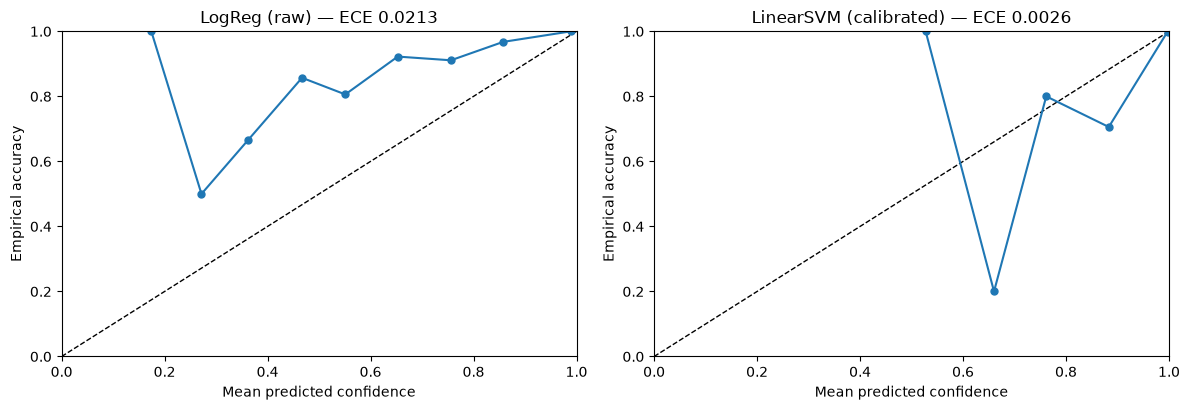

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, (name, d) in zip(axes, [("LogReg (raw)", cal_lr), ("LinearSVM (calibrated)", cal_svc)]):
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.plot(d["calibration_curve"]["confidence"], d["calibration_curve"]["accuracy"], "o-", ms=5)
    ax.set_xlabel("Mean predicted confidence"); ax.set_ylabel("Empirical accuracy")
    ax.set_title(f"{name} — ECE {d['ece']:.4f}")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

## 14. Abstention / Human-Review Simulation

**Objective** — how does confidence-based abstention trade off automation
coverage vs. accuracy?

**Method** — confidence-aware selective prediction on the same
fair-protocol calibrated hybrid LogReg used in Section 13.  Accept only
predictions with `max(p) ≥ τ` for τ ∈ {0.5, 0.6, 0.7, 0.8, 0.9, 0.95,
0.99}; measure coverage, accuracy and Macro-F1 over accepted items.

**Result** — coverage–accuracy trade-off table (a final project output).

In [41]:
sel = tx.selective_prediction(df, seed=42)
sel_rows = pd.DataFrame(sel["rows"]).T.reset_index(drop=True)
sel_rows = sel_rows[["threshold", "coverage", "abstention_rate", "accuracy", "macro_f1", "accepted_count"]]
sel_rows

,threshold,coverage,abstention_rate,accuracy,macro_f1,accepted_count
0,0.50,0.9960,0.0040,0.9963,0.9963,13545.0
1,0.60,0.9910,0.0090,0.9973,0.9972,13478.0
2,0.70,0.9835,0.0165,0.9978,0.9978,13375.0
3,0.80,0.9727,0.0273,0.9988,0.9988,13229.0
4,0.90,0.9432,0.0568,0.9998,0.9998,12828.0
5,0.95,0.9015,0.0985,0.9999,0.9999,12260.0
6,0.99,0.6399,0.3601,1.0000,1.0000,8703.0


In [42]:
tx.write_json(sel, Path("out") / "selective_prediction.json")
print("saved out/selective_prediction.json")

saved out/selective_prediction.json


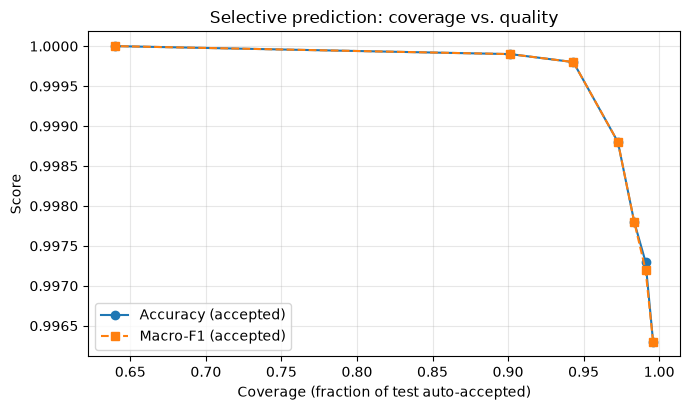

In [43]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(sel_rows["coverage"], sel_rows["accuracy"], "o-", label="Accuracy (accepted)")
ax.plot(sel_rows["coverage"], sel_rows["macro_f1"], "s--", label="Macro-F1 (accepted)")
ax.set_xlabel("Coverage (fraction of test auto-accepted)")
ax.set_ylabel("Score")
ax.set_title("Selective prediction: coverage vs. quality")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 15. Error Analysis

**Objective** — characterize the dominant failure modes.

**Method** — confusion analysis on the best model, per-class F1 ranking,
and representative misclassifications with confidence.

In [44]:
best_key = max(metrics, key=lambda k: metrics[k]["macro_f1"])
best_model = models[best_key]
print("Best model by random-split Macro-F1:", best_key)

bestm = metrics[best_key]
per_class = {
    k: v for k, v in bestm["classification_report"].items()
    if k not in ("accuracy", "macro avg", "weighted avg")
}
per_class_df = pd.DataFrame(per_class).T[["precision", "recall", "f1-score", "support"]].sort_values("f1-score")
print("Worst 5 categories:")
print(per_class_df.head(5).to_string())
print()
print("Best 5 categories:")
print(per_class_df.tail(5).to_string())

Best model by random-split Macro-F1: linearsvc
Worst 5 categories:
               precision   recall  f1-score  support
Shopping        1.000000  0.97875  0.989261    800.0
Healthcare      0.985222  1.00000  0.992556    800.0
Personal Care   0.996264  1.00000  0.998129    800.0
Transfer        0.997506  1.00000  0.998752    800.0
Groceries       1.000000  1.00000  1.000000    800.0

Best 5 categories:
                precision  recall  f1-score  support
Restaurants           1.0     1.0       1.0    800.0
Subscription          1.0     1.0       1.0    800.0
Transportation        1.0     1.0       1.0    800.0
Travel                1.0     1.0       1.0    800.0
Utilities             1.0     1.0       1.0    800.0


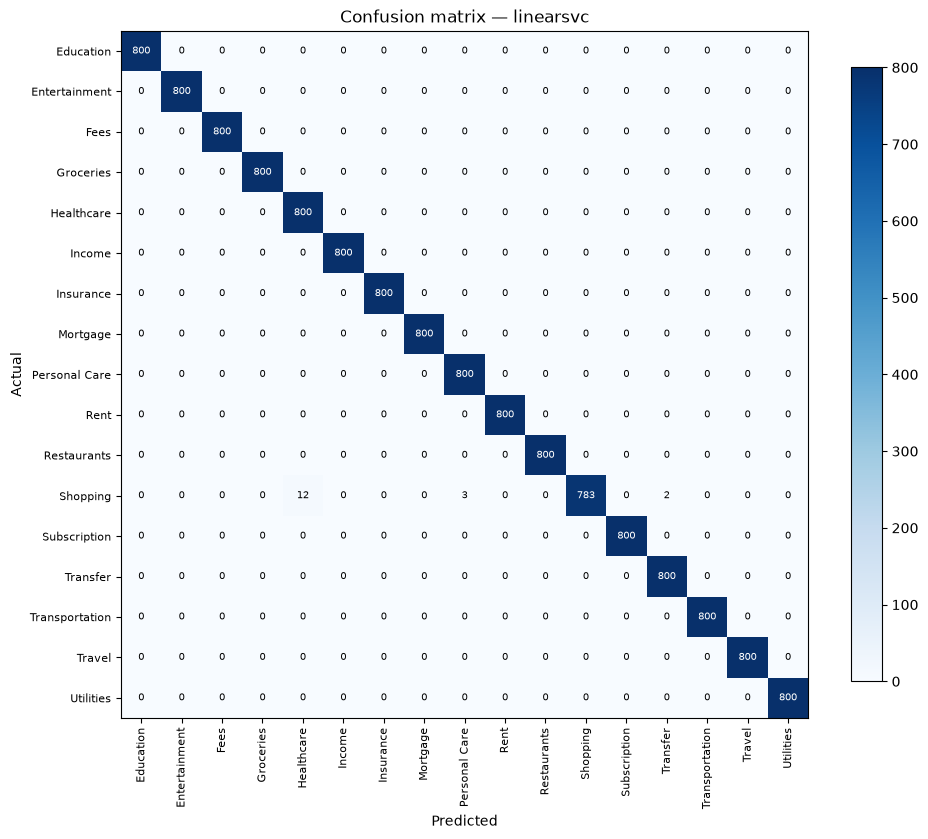

In [45]:
from sklearn.metrics import confusion_matrix
import itertools

cm = confusion_matrix(test_df["category"].values, best_model.predict(Xte_full), labels=labels)
fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
thr = cm.max() / 2
for i, j in itertools.product(range(len(labels)), range(len(labels))):
    ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
            fontsize=7, color="white" if cm[i, j] > thr else "black")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — {best_key}")
fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout(); plt.show()

In [46]:
# Fair error analysis: inspect the *actual* best model from Section 10
# (word+char+dir+struct hybrid), not a freshly-fit word-only LR.
er = tx.error_analysis(
    df,
    seed=42,
    prefit={
        "model":   best_model,
        "X_test":  Xte_full,
        "test_df": test_df,
        "labels":  labels,
    },
)
print("Misclassification rate:", er["misclassification_rate"])
err_df = pd.DataFrame(er["examples"])[["true", "predicted", "description", "confidence"]]
err_df.head(25)

Misclassification rate: 0.0013


,true,predicted,description,confidence
0,Shopping,Healthcare,[credit] PAYPAL INST XFER CVS WEB ID: PAYPALSI19,None
1,Shopping,Healthcare,[debit] PP*RITE AID,None
2,Shopping,Healthcare,[debit] CVS #88888 SAN JOSE,None
3,Shopping,Transfer,[debit] PAYPAL INST XFER H&M WEB ID: PAYPALSI29,None
4,Shopping,Healthcare,[debit] CVS #3378 DALLAS,None
5,Shopping,Healthcare,[debit] WALGREENS #5389 BOSTON,None
6,Shopping,Transfer,[debit] PAYPAL INST XFER H&M WEB ID: PAYPALSI77,None
7,Shopping,Healthcare,[debit] Cvs #8182 New York,None
8,Shopping,Healthcare,[debit] PYPL*RITE AID,None
9,Shopping,Healthcare,[debit] CVS 9093,None


In [47]:
tx.write_json(er, Path("out") / "error_analysis.json")
print("saved out/error_analysis.json")

saved out/error_analysis.json


## 16. Data-Efficiency / Learning Curve

**Objective** — is the project data-limited? Does more labeled data help?

**Method** — fixed test set; training sizes 5K / 10K / 20K / 40K / full.
Same preprocessing, same model, same hyperparameters, same test set.

**Result** — training size vs Macro-F1.

In [48]:
lc = tx.learning_curve(df, train_sizes=(5_000, 10_000, 20_000, 40_000), seed=42)
lc_rows = pd.DataFrame(lc["rows"])
lc_rows

2026-08-18 02:46:28 | INFO     | learning_curve::5000 — Acc 0.9144  Macro-F1 0.9143  W-F1 0.9143


2026-08-18 02:46:34 | INFO     | learning_curve::10000 — Acc 0.9599  Macro-F1 0.9599  W-F1 0.9599


2026-08-18 02:46:40 | INFO     | learning_curve::20000 — Acc 0.9831  Macro-F1 0.9831  W-F1 0.9831


2026-08-18 02:46:53 | INFO     | learning_curve::40000 — Acc 0.9924  Macro-F1 0.9924  W-F1 0.9924


,train_size,accuracy,macro_f1
0,5000,0.9144,0.9143
1,10000,0.9599,0.9599
2,20000,0.9831,0.9831
3,40000,0.9924,0.9924


In [49]:
# add the full-train point from the random-split model
lc_rows.loc[len(lc_rows)] = {"train_size": len(train_df), "accuracy": hybrid_metrics["accuracy"], "macro_f1": hybrid_metrics["macro_f1"]}
tx.write_json({"rows": lc_rows.to_dict("records")}, Path("out") / "learning_curve.json")
print("saved out/learning_curve.json")

saved out/learning_curve.json


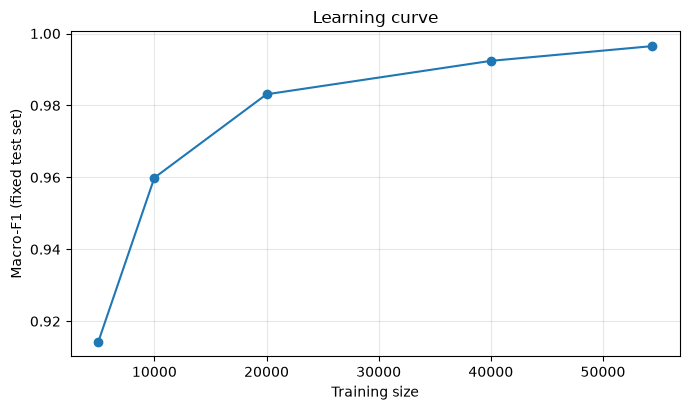

In [50]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(lc_rows["train_size"], lc_rows["macro_f1"], "o-")
ax.set_xlabel("Training size"); ax.set_ylabel("Macro-F1 (fixed test set)")
ax.set_title("Learning curve")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 17. Merchant-Memorization Ablation & Final Model Selection

**Objective** — isolate the contribution of merchant identity vs.
generalizable transaction language, then select the final model.

**Method** — on the merchant-disjoint split, evaluate four description
conditions: full, merchant tokens masked, identifiers masked, both masked.
The gap between "full" and "merchant-masked" quantifies reliance on merchant
identity.

In [51]:
mem_abl = tx.merchant_ablation(df, seed=42)
pd.DataFrame(mem_abl).T.rename(columns={"accuracy": "Accuracy", "macro_f1": "Macro-F1"})

2026-08-18 02:47:04 | INFO     | ablation::full — Acc 0.9429  Macro-F1 0.9440  W-F1 0.9427


2026-08-18 02:47:19 | INFO     | ablation::merchant_masked — Acc 0.3159  Macro-F1 0.3557  W-F1 0.3445


2026-08-18 02:47:29 | INFO     | ablation::ids_masked — Acc 0.9071  Macro-F1 0.9097  W-F1 0.9088


2026-08-18 02:47:38 | INFO     | ablation::merchant_ids_masked — Acc 0.2797  Macro-F1 0.3027  W-F1 0.2899


,Accuracy,Macro-F1
full,0.9429,0.9440
merchant_masked,0.3159,0.3557
ids_masked,0.9071,0.9097
merchant_ids_masked,0.2797,0.3027


In [52]:
tx.write_json(mem_abl, Path("out") / "merchant_ablation.json")
print("saved out/merchant_ablation.json")

saved out/merchant_ablation.json


## 18. Conclusions

### Final results

The final model is selected on merchant-disjoint Macro-F1, standard Macro-F1,
calibration quality, complexity, and selective-prediction behavior — not on
random-split accuracy alone.

In [53]:
final = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM", "XGBoost"],
    "Representation": ["word+char+dir+struct"] * 3,
    "Random Macro-F1": [metrics["logreg"]["macro_f1"], metrics["linearsvc"]["macro_f1"], metrics["xgboost"]["macro_f1"]],
    "Merchant-Disjoint Macro-F1": [gen_metrics["logreg"]["macro_f1"], gen_metrics["linearsvc"]["macro_f1"], gen_metrics["xgboost"]["macro_f1"]],
})
final["Δ"] = (final["Merchant-Disjoint Macro-F1"] - final["Random Macro-F1"]).round(4)
final

,Model,Representation,Random Macro-F1,Merchant-Disjoint Macro-F1,Δ
0,Logistic Regression,word+char+dir+struct,0.9959,0.9516,-0.0443
1,Linear SVM,word+char+dir+struct,0.9987,0.9588,-0.0399
2,XGBoost,word+char+dir+struct,0.9902,0.8786,-0.1116


In [54]:
# Summary block
summary_out = {
    "dataset": {
        "rows": int(len(df)),
        "categories": int(df["category"].nunique()),
        "merchants": int(df["merchant"].nunique()),
        "formats": {k: int(v) for k, v in df["format"].value_counts().items()},
    },
    "best_model": best_key,
    "representation": "word+char+dir+struct",
    "random_macro_f1": metrics[best_key]["macro_f1"],
    "merchant_disjoint_macro_f1": gen_metrics[best_key]["macro_f1"],
    "merchant_disjoint_drop": round(gen_metrics[best_key]["macro_f1"] - metrics[best_key]["macro_f1"], 4),
    "calibration_ece_best": min(cal_lr["ece"], cal_svc["ece"]),
    "selective_prediction": {k: {kk: (float(vv) if isinstance(vv, (int, float, np.floating)) else vv) for kk, vv in v.items()} for k, v in sel["rows"].items()},
}
print(json.dumps(summary_out, indent=2))

{
  "dataset": {
    "rows": 68000,
    "categories": 17,
    "merchants": 12918,
    "formats": {
      "simple": 45386,
      "ach": 8272,
      "paypal": 5732,
      "address": 4670,
      "capital_one": 2791,
      "pos": 1149
    }
  },
  "best_model": "linearsvc",
  "representation": "word+char+dir+struct",
  "random_macro_f1": 0.9987,
  "merchant_disjoint_macro_f1": 0.9588,
  "merchant_disjoint_drop": -0.0399,
  "calibration_ece_best": 0.0026,
  "selective_prediction": {
    "0.5": {
      "threshold": 0.5,
      "coverage": 0.996,
      "abstention_rate": 0.004,
      "accuracy": 0.9963,
      "macro_f1": 0.9963,
      "accepted_count": 13545.0
    },
    "0.6": {
      "threshold": 0.6,
      "coverage": 0.991,
      "abstention_rate": 0.009,
      "accuracy": 0.9973,
      "macro_f1": 0.9972,
      "accepted_count": 13478.0
    },
    "0.7": {
      "threshold": 0.7,
      "coverage": 0.9835,
      "abstention_rate": 0.0165,
      "accuracy": 0.9978,
      "macro_f1": 0.9978,

In [55]:
print("=" * 70)
print("DATASET")
print(f"  rows={len(df):,}  categories={df['category'].nunique()}  "
      f"merchants={df['merchant'].nunique():,}  formats={df['format'].nunique()}")
print()
print("BEST MODEL")
print(f"  {best_key}  |  representation = word+char+dir+struct")
print(f"  random Macro-F1 = {metrics[best_key]['macro_f1']:.4f}")
print(f"  merchant-disjoint Macro-F1 = {gen_metrics[best_key]['macro_f1']:.4f}")
print()
print("GENERALIZATION")
print(f"  Δ Macro-F1 = {gen_metrics[best_key]['macro_f1'] - metrics[best_key]['macro_f1']:+.4f}")
print()
print("CALIBRATION")
print(f"  best ECE = {min(cal_lr['ece'], cal_svc['ece']):.4f}")
print()
print("SELECTIVE PREDICTION")
best_sel = min(sel["rows"].values(), key=lambda r: abs(r.get("accuracy", 0) - 0.99) if r.get("accuracy") else 1e9)
if best_sel and best_sel.get("accuracy"):
    print(f"  threshold={best_sel['threshold']}  coverage={best_sel['coverage']:.2f}  accuracy={best_sel['accuracy']:.4f}")
print("=" * 70)

DATASET
  rows=68,000  categories=17  merchants=12,918  formats=6

BEST MODEL
  linearsvc  |  representation = word+char+dir+struct
  random Macro-F1 = 0.9987
  merchant-disjoint Macro-F1 = 0.9588

GENERALIZATION
  Δ Macro-F1 = -0.0399

CALIBRATION
  best ECE = 0.0026

SELECTIVE PREDICTION
  threshold=0.5  coverage=1.00  accuracy=0.9963
